# Batch TCA Pipeline

Runs TCA with 4 replicas and 10 components for each target file and alignment (tunnel entrance, sound cue).
Saves ensembles in the same format as tpca.ipynb (pickle with metadata). Loads, visualizes, and saves figures.

**Step 1:** Paths, imports, load one target's spikes + behavior.  
**Step 2:** Build 3D tensor (neurons × time × trials) with small buffer + subset of trials.  
**Step 2b:** Speed-based correction of neural activity (Option B: regress out running speed with trial identity; before/after heatmaps for BUFFER_TUNNEL / BUFFER_SOUND).  
**Step 3:** Run TCA on small tensor (ranks 1–3, 2 replicas), compute elbow + best_rep_idx, plot objective/similarity.  
**Step 4:** Save payload (tpca format + ordering + trial metadata) to pickle; load and verify.  
**Step 5:** Load from pickle and visualize factors (same grid and colors as tpca: U scatter, V line, W scatter; TrialStim palette; area if in payload).

## Imports and paths

In [1]:
from pathlib import Path
import os
import numpy as np
import pandas as pd

# Resolve project root (folder containing 'data')
base = Path.cwd()
for p in [base, *base.parents]:
    if (p / 'data').exists():
        project_root = p
        break
else:
    project_root = base

data_root = str(project_root / 'data')
results_dir = project_root / 'results' / '4replicas_10components_10frames'
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Data root: {data_root}")
print(f"Results dir: {results_dir}")

Data root: /Users/johnmadrid/GitHub/isp-unsupervised-learning/data
Results dir: /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/4replicas_10components_10frames


## Target files and behavior paths

In [2]:
# Same target identifiers as Batch_TCA_Runner and tpca
sup_bef = 'VR2_2021_03_20_1'
sup_aft = 'VR2_2021_04_06_1'
unsup_bef = 'TX105_2022_10_08_2'
unsup_aft = 'TX105_2022_10_19_2'

def get_beh_path(target_file):
    """Return behavior .npy filename for a target file."""
    if target_file == sup_bef:
        return 'Beh_sup_train1_before_learning.npy'
    if target_file == sup_aft:
        return 'Beh_sup_train1_after_learning.npy'
    if target_file == unsup_bef:
        return 'Beh_unsup_train1_before_learning.npy'
    if target_file == unsup_aft:
        return 'Beh_unsup_train1_after_learning.npy'
    raise ValueError(f"Unknown target_file: {target_file}")

# For Step 1 we use a single target
target_file = sup_bef
beh_filename = get_beh_path(target_file)
beh_path = os.path.join(data_root, beh_filename)
spike_path = os.path.join(data_root, target_file + '_SVD_dec.npy')

print(f"Target: {target_file}")
print(f"Spike file: {spike_path}")
print(f"Beh file: {beh_path}")

Target: VR2_2021_03_20_1
Spike file: /Users/johnmadrid/GitHub/isp-unsupervised-learning/data/VR2_2021_03_20_1_SVD_dec.npy
Beh file: /Users/johnmadrid/GitHub/isp-unsupervised-learning/data/Beh_sup_train1_before_learning.npy


## Load spikes and behavior (one target)

In [3]:
# Load spike data (SVD-decomposed)
# U.T @ V gives (n_neurons, n_time); transpose so time is first axis for create_3d_matrix
svd_data = np.load(spike_path, allow_pickle=True).item()
spikes = (svd_data['U'].T @ svd_data['V']).T  # (n_timepoints, n_neurons)

# Load behavior for this target
beh_all = np.load(beh_path, allow_pickle=True).item()
beh = beh_all[target_file]

n_timepoints, n_neurons = spikes.shape
print(f"Spikes shape: {spikes.shape} = ({n_timepoints} timepoints x {n_neurons} neurons)")
print(f"Behavior keys: {list(beh.keys())[:10]}... (total {len(beh)} keys)")

Spikes shape: (24298, 81473) = (24298 timepoints x 81473 neurons)
Behavior keys: ['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime']... (total 59 keys)


In [4]:
print(beh.keys())

dict_keys(['ntrials', 'trInd', 'trInd_odd', 'trInd_even', 'Trial_start_time', 'Trial_end_time', 'SubjMove', 'Gray_space_time', 'SoundPos', 'SoundTime', 'SoundTimeDelay', 'RewTime', 'RewPos', 'isRew', 'WallType', 'WallIsProbe', 'WallName', 'UniqWalls', 'LickTrind', 'LickTime', 'LickPos', 'Lick_wallName', 'VRposTime', 'VRpos', 'VRposCum', 'ft', 'ft_trInd', 'ft_trInd_odd', 'ft_trInd_even', 'ft_PosCum', 'ft_Pos', 'ft_move', 'ft_isMoving', 'ft_GraySpc', 'ft_CorrSpc', 'ft_WallID', 'ft_RunCum', 'ft_RunSpeed', 'Corridor_Length', 'Gray_Space_length', 'Texture_Length', 'run_pos', 'RewardFr', 'StartFr', 'GrayFr', 'EndFr', 'LickFr', 'SoundFr', 'SoundDelayFr', 'SoundDelPos', 'RunFr', 'BefCueFr', 'AftCueFr', 'stim_id', 'TrialStim', 'StimTrial', 'StimFrame', 'Reward_Mode', 'Reward_Delay_ms'])


## Neuron area from trans file (before TCA)

Load the trans file for this recording and build `neuron_to_area` (neuron index → area name), same logic as tpca's `add_area_label_to_melted_spikes`. Required so we can save it in the payload and use it in factor visualization.

In [5]:
def load_neuron_to_area_from_trans(root, recording_name):
    """Load trans file and return Series mapping neuron index (0..n-1) → area name. Same iarea→area map as tpca."""
    # Trans file: recording_name with last character removed + 'trans.npz' (e.g. VR2_2021_03_20_1 → VR2_2021_03_20_trans.npz)
    filename = os.path.join(root, recording_name[:-1] + "trans.npz")
    with np.load(filename, allow_pickle=True) as retin:
        retin_df = pd.DataFrame({"iarea": retin["iarea"]})
    retin_df["neuron"] = retin_df.index.astype(int)
    # Same area mapping as tpca
    area_map_dict = pd.Series({
        8: "V1", 0: "mHV", 1: "mHV", 2: "mHV", 9: "mHV",
        5: "lHV", 6: "lHV", 3: "aHV", 4: "aHV",
    })
    retin_df["area"] = retin_df["iarea"].map(area_map_dict).fillna("Other")
    neuron_to_area = retin_df.set_index("neuron")["area"]
    return neuron_to_area

neuron_to_area = load_neuron_to_area_from_trans(data_root, target_file)
# Sanity check: length should match n_neurons from spikes
assert len(neuron_to_area) == n_neurons, f"Trans neurons {len(neuron_to_area)} vs spike neurons {n_neurons}"
print(f"neuron_to_area: {len(neuron_to_area)} neurons, areas: {neuron_to_area.unique().tolist()}")

neuron_to_area: 81473 neurons, areas: ['V1', 'Other', 'lHV', 'aHV', 'mHV']


## Sanity check: alignment timestamps (one trial)

In [6]:
# Buffers we will use later: tunnel (2 before, 8 after), sound (5 before, 5 after)
BUFFER_TUNNEL = (2, 8)   # frames before/after tunnel entrance (Trial_start_time)
BUFFER_SOUND = (5, 5)    # frames before/after sound cue (SoundTime)

# One trial: show Trial_start_time and SoundTime
trial_idx = 0
t_start = beh['Trial_start_time'][trial_idx]
t_sound = beh['SoundTime'][trial_idx]
ft = beh['ft'][: min(len(beh['ft']), spikes.shape[0] + 1)]

print(f"Trial {trial_idx}: Trial_start_time = {t_start}, SoundTime = {t_sound}")
print(f"Behavior 'ft' length: {len(ft)}, spikes timepoints: {spikes.shape[0]}")
print(f"Number of trials (Trial_start_time): {len(beh['Trial_start_time'])}")

Trial 0: Trial_start_time = 738235.7096927778, SoundTime = 738235.7097275
Behavior 'ft' length: 24299, spikes timepoints: 24298
Number of trials (Trial_start_time): 348


## Step 2: Build 3D tensor (neurons × time × trials)

`create_3d_matrix` returns shape **(n_neurons, n_time, n_trials)** so TCA factors are (U, V, W) = (neurons, time, trials) with no transpose.  
We test with a **small buffer** and **subset of trials** to verify shapes.

In [7]:
def create_3d_matrix(trial_timestamps, buffer, spiking_data, spiking_timestamps):
    """
    Build 3D tensor for TCA with shape (n_neurons, n_time, n_trials).
    So TCA factors will be U (neurons), V (time), W (trials) with no reordering.

    trial_timestamps: array of timestamps to center each trial window on
    buffer: (n_before, n_after) frames left/right of the timestamp
    spiking_data: (n_timepoints, n_neurons)
    spiking_timestamps: timestamps for each row of spiking_data
    """
    n_trials = len(trial_timestamps)
    n_time = buffer[0] + buffer[1] + 1
    n_neurons = spiking_data.shape[1]
    tensor = np.zeros((n_neurons, n_time, n_trials), dtype=np.float32)
    for index, timestamp in enumerate(trial_timestamps):
        idx = np.searchsorted(spiking_timestamps, timestamp, side='right')
        # slice (n_time,) x (n_neurons); .T -> (n_neurons, n_time)
        tensor[:, :, index] = spiking_data[idx - buffer[0] : idx + buffer[1] + 1, :].T
    return tensor

In [8]:
# Step 2 test: small buffer and subset of trials (run after loading spikes + beh above)
ft = beh['ft'][: spikes.shape[0] + 1]
trial_timestamps = beh['SoundTime']
# trial_timestamps = beh['Trial_start_time'] 

# Small test: 4 time frames (1 before + 2 after center), 20 trials
buffer_small = BUFFER_SOUND  # (2, 8)   # 1 + 2 + 1 = 4 frames
n_trials_test = 348
trial_ts_test = trial_timestamps[:n_trials_test]

tensor_small = create_3d_matrix(trial_ts_test, buffer_small, spikes, ft)
n_neurons, n_time, n_trials = tensor_small.shape
print(f"Tensor shape: {tensor_small.shape} = (n_neurons={n_neurons}, n_time={n_time}, n_trials={n_trials})")
print(f"Min: {tensor_small.min():.4f}, Max: {tensor_small.max():.4f}, Mean: {tensor_small.mean():.4f}")

Tensor shape: (81473, 11, 348) = (n_neurons=81473, n_time=11, n_trials=348)
Min: -5.0796, Max: 44.1074, Mean: 0.1217


## Step 2b: Speed-based correction of neural activity (Option B)

We correct for running speed by regressing neural activity on speed and using **residuals** as the speed-corrected signal. Two common approaches in the literature:

- **Option A (simple model):** `activity ~ 1 + speed` — one regression per neuron across all (frame, trial) points. Removes both within-trial and across-trial speed-related variance. Used in continuous/spontaneous designs where trial identity is not of interest (e.g. **Stringer et al., *Science* 2019**, "Spontaneous behaviors drive multidimensional, brainwide activity"; wide-field locomotion studies that regress out a global effect of speed).
- **Option B (trial in the model):** `activity ~ 1 + speed + trial` — same, but with **trial identity** as a categorical covariate. Removes only **within-trial** modulation by speed; trial-to-trial (and thus TrialStim) mean differences are preserved in the residuals.

**Why we use Option B:** Our pipeline is trial-based (TCA over neurons × time × **trials**, and we visualize by TrialStim). We want to remove the confound (moment-by-moment speed) but **keep** trial/condition structure for factors and heatmaps. Option B is the appropriate choice for trial-based factor or decoding analyses (standard in neuroimaging when controlling a continuous confound while preserving condition/trial identity).

**References:**
- **Option A:** Stringer et al. (2019) *Science* — "Spontaneous behaviors drive multidimensional, brainwide activity"; wide-field calcium imaging during locomotion (e.g. *Nat. Commun.*).
- **Option B:** Standard practice when the analysis is trial- or condition-based and the goal is to strip within-trial confounds while retaining trial/condition means (e.g. trial-based TCA, decoding, or factor visualization).

In [9]:
# Build speed matrix (n_time, n_trials) aligned with create_3d_matrix windows (vectorized, no Python loop)
def create_speed_matrix(trial_timestamps, buffer, spiking_timestamps, run_speed):
    n_trials = len(trial_timestamps)
    n_time = buffer[0] + buffer[1] + 1
    idx = np.searchsorted(spiking_timestamps, trial_timestamps, side='right')  # (n_trials,)
    # (n_time, n_trials) array of global frame indices; advanced indexing returns (n_time, n_trials)
    speed_matrix = run_speed[np.arange(n_time)[:, None] + (idx - buffer[0])].astype(np.float32)
    return speed_matrix

# Option B: activity ~ 1 + speed + trial; return residual tensor (same shape). Pure NumPy, no pandas.
def speed_correct_tensor(tensor, speed_matrix, n_neurons, n_time, n_trials, correct_by="bytrial"):
    """correct_by: 'simple' -> activity ~ 1+speed (Option A); 'bytrial' -> activity ~ 1+speed+trial (Option B)."""
    n_obs = n_time * n_trials
    speed_flat = speed_matrix.ravel()
    intercept = np.ones((n_obs, 1), dtype=np.float64)
    speed_col = speed_flat.reshape(-1, 1)
    if correct_by == "simple":
        X = np.hstack([intercept, speed_col])  # (n_obs, 2)
    elif correct_by == "bytrial":
        trial_idx = np.repeat(np.arange(n_trials), n_time)
        trial_dummies = (trial_idx[:, None] == np.arange(1, n_trials)).astype(np.float64)
        X = np.hstack([intercept, speed_col, trial_dummies])
    else:
        raise ValueError('correct_by must be "simple" or "bytrial"')

    # Y: (n_obs, n_neurons) — one column per neuron
    Y = tensor.reshape(n_neurons, n_obs).T  # (n_obs, n_neurons)

    # Single batched solve: B = (X'X)^{-1} X' Y  ->  (n_features, n_neurons)
    B = np.linalg.lstsq(X, Y, rcond=None)[0]

    # Residuals: (n_obs, n_neurons) -> (n_neurons, n_time, n_trials)
    residuals = (Y - X @ B).T.reshape(n_neurons, n_time, n_trials)
    return residuals.astype(np.float32)

# Single-target BUFFER_TUNNEL: raw tensor, speed matrix, corrected tensor
correct_by = "simple"  # "simple" (Option A) or "bytrial" (Option B)
ft = beh['ft'][: spikes.shape[0] + 1]
run_speed = beh['ft_RunSpeed'][: len(ft)]
trial_timestamps_tunnel = beh['SoundTime']
tensor_tunnel_raw = create_3d_matrix(trial_timestamps_tunnel, BUFFER_TUNNEL, spikes, ft)
n_neurons, n_time, n_trials = tensor_tunnel_raw.shape
speed_matrix_tunnel = create_speed_matrix(trial_timestamps_tunnel, BUFFER_TUNNEL, ft, run_speed)
tensor_tunnel_corrected = speed_correct_tensor(
    tensor_tunnel_raw, speed_matrix_tunnel, n_neurons, n_time, n_trials, correct_by=correct_by
)
print(f"BUFFER_TUNNEL: raw {tensor_tunnel_raw.shape}, corrected {tensor_tunnel_corrected.shape}")
print(f"Raw min/max/mean: {tensor_tunnel_raw.min():.4f} / {tensor_tunnel_raw.max():.4f} / {tensor_tunnel_raw.mean():.4f}")
print(f"Residual min/max/mean: {tensor_tunnel_corrected.min():.4f} / {tensor_tunnel_corrected.max():.4f} / {tensor_tunnel_corrected.mean():.4f}")

BUFFER_TUNNEL: raw (81473, 11, 348), corrected (81473, 11, 348)
Raw min/max/mean: -5.0796 / 26.0897 / 0.0966
Residual min/max/mean: -5.0085 / 26.0754 / -0.0000


In [10]:
# Melt tensor to long DataFrame (trial-averaged per TrialStim) for heatmaps
def tensor_to_melted_df(tensor, buffer, trial_order, trial_to_stim, neuron_to_area):
    n_neurons, n_time, n_trials = tensor.shape
    frame_order = np.arange(-buffer[0], buffer[1] + 1, dtype=int)
    stims = pd.Series([trial_to_stim.get(trial_order[tr], None) for tr in range(n_trials)]).dropna().unique()
    area_get = (lambda n: neuron_to_area.get(n, 'Other')) if isinstance(neuron_to_area, dict) else (lambda n: neuron_to_area.get(n, 'Other'))
    rows = []
    for stim in stims:
        trial_mask = np.array([trial_to_stim.get(trial_order[tr], None) == stim for tr in range(n_trials)])
        mean_activity = tensor[:, :, trial_mask].mean(axis=2)
        for n in range(n_neurons):
            for t in range(n_time):
                rows.append({'neuron': n, 'frame': frame_order[t], 'spike_value': float(mean_activity[n, t]), 'TrialStim': stim, 'area': area_get(n)})
    return pd.DataFrame(rows)

# Heatmaps: neuron x frame per TrialStim, neurons sorted by area (from tpca.ipynb)
def plot_trialstim_heatmaps(melted_df, ncols=2, figsize_per_plot=(4, 6), cmap='viridis', aggfunc='mean', save=False, name='', save_dir=None):
    import matplotlib.pyplot as plt
    from pathlib import Path
    required = {'neuron', 'frame', 'spike_value', 'TrialStim', 'area'}
    if required - set(melted_df.columns): raise KeyError(f"Missing: {required - set(melted_df.columns)}")
    stims = melted_df['TrialStim'].dropna().unique()
    n, ncols = len(stims), max(1, min(ncols, len(stims)))
    nrows = int(np.ceil(n / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows), sharey=True)
    axes = np.atleast_1d(axes).ravel()
    first_mappable, vmin, vmax = None, -1, 3
    neuron_area_df = melted_df[['neuron', 'area']].drop_duplicates()
    area_order = sorted(neuron_area_df['area'].unique())
    parts = []
    for a in area_order:
        g = neuron_area_df[neuron_area_df['area'] == a].copy()
        try: g = g.assign(neuron_sorted=g['neuron'].astype(int)).sort_values('neuron_sorted')
        except Exception: g = g.sort_values('neuron')
        parts.append(g)
    neuron_order_df = pd.concat(parts)
    neuron_order = neuron_order_df['neuron'].values
    neuron_to_area_map = neuron_order_df.set_index('neuron')['area']
    for i, stim in enumerate(stims):
        ax = axes[i]
        heatmap_df = melted_df[melted_df['TrialStim'] == stim].pivot_table(index='neuron', columns='frame', values='spike_value', aggfunc=aggfunc)
        heatmap_df = heatmap_df.reindex([x for x in neuron_order if x in heatmap_df.index])
        data, fv = heatmap_df.values, heatmap_df.columns.to_numpy()
        x_min, x_max = (np.nanmin(fv), np.nanmax(fv)) if fv.size else (0, data.shape[1])
        im = ax.imshow(data, aspect='auto', interpolation='nearest', cmap=cmap, extent=[x_min, x_max, 0, data.shape[0]], vmin=vmin, vmax=vmax)
        if first_mappable is None: first_mappable = im
        ax.set_title(f"TrialStim: {stim}"); ax.set_xlabel("Frame"); ax.set_ylabel("Neuron (by area)"); ax.axvline(x=0, color='red', linestyle='--', linewidth=1)
    for j in range(i + 1, len(axes)): axes[j].axis('off')
    plt.tight_layout(rect=[0, 0, 0.80, 1])
    if first_mappable is not None: fig.subplots_adjust(right=0.80); fig.colorbar(first_mappable, cax=fig.add_axes([0.82, 0.15, 0.02, 0.7]), orientation='vertical', label='spike_value')
    if save: out_dir = Path(save_dir) if save_dir else Path('results'); out_dir.mkdir(parents=True, exist_ok=True); out_path = out_dir / f"trialstim_heatmaps_{name}.png"; fig.savefig(out_path, dpi=300, bbox_inches='tight'); print(f"Saved: {out_path}")
    return

In [11]:
# Build melted DFs and plot before/after speed correction for BUFFER_TUNNEL
trial_order_tunnel = np.asarray(beh['trInd'][:n_trials], dtype=int)
trial_to_stim_tunnel = dict(zip(trial_order_tunnel, beh['TrialStim'][:n_trials]))
neuron_to_area_dict = neuron_to_area.to_dict() if hasattr(neuron_to_area, 'to_dict') else neuron_to_area
melted_tunnel_raw = tensor_to_melted_df(tensor_tunnel_raw, BUFFER_SOUND, trial_order_tunnel, trial_to_stim_tunnel, neuron_to_area_dict)
melted_tunnel_corrected = tensor_to_melted_df(tensor_tunnel_corrected, BUFFER_SOUND, trial_order_tunnel, trial_to_stim_tunnel, neuron_to_area_dict)
# plot_trialstim_heatmaps(melted_tunnel_raw, save=True, name=f'{target_file}_tunnel_before_speed_correction', save_dir=results_dir)

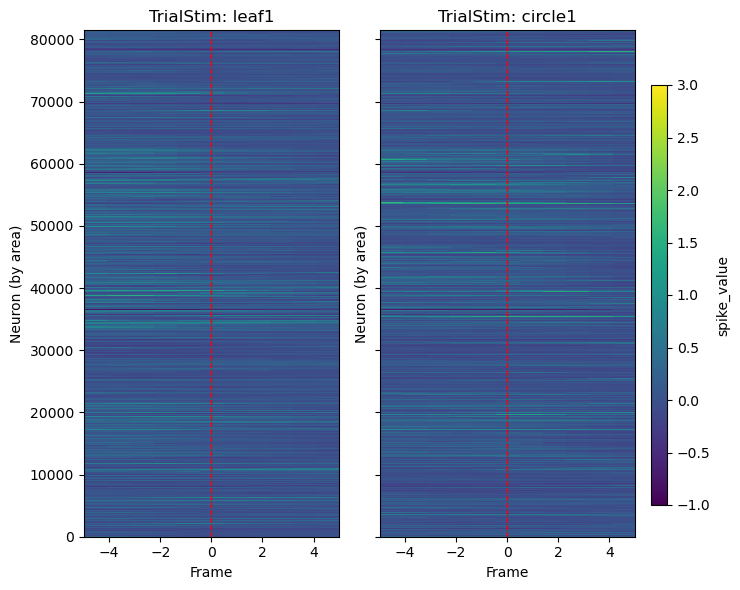

In [12]:
# visualize before speed correction
plot_trialstim_heatmaps(melted_tunnel_raw, save=False, name=f'{target_file}_tunnel_before_speed_correction', save_dir=results_dir)

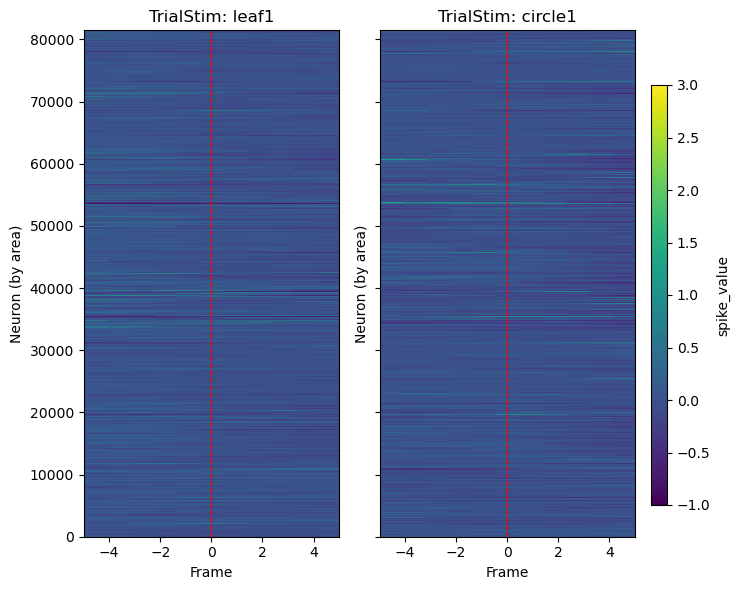

In [13]:
# visualize after speed correction
plot_trialstim_heatmaps(melted_tunnel_corrected, save=False, name=f'{target_file}_tunnel_after_SIMPLE_speed_correction', save_dir=results_dir)

## Step 3: Run TCA and compute best rank (elbow)

Fit ensemble on the small tensor with ranks 1–3 and 2 replicas. Compute mean reconstruction error per rank, best replicate per rank, and elbow-based `best_rank`. Plot objective and similarity with **descriptive titles** (target, alignment, buffer, rank range, replicates, best_rank) and **save** the figure to `results/4replicas_10components_10frames/` using the naming convention:  
`objective_similarity_{target_file}_{alignment}_buffer{n}-{n}_r{min}-{max}_rep{n}_best{n}.png`

Rank-1 models:  min obj, 0.97;  max obj, 0.97;  time to fit, 143.2s


Rank-2 models:  min obj, 0.95;  max obj, 0.95;  time to fit, 229.1s


Rank-3 models:  min obj, 0.94;  max obj, 0.94;  time to fit, 258.5s


Rank-4 models:  min obj, 0.92;  max obj, 0.93;  time to fit, 597.9s


Rank-5 models:  min obj, 0.91;  max obj, 0.92;  time to fit, 780.0s


Rank-6 models:  min obj, 0.91;  max obj, 0.91;  time to fit, 665.3s


Rank-7 models:  min obj, 0.90;  max obj, 0.90;  time to fit, 1213.4s


Rank-8 models:  min obj, 0.89;  max obj, 0.89;  time to fit, 1020.4s


Rank-9 models:  min obj, 0.88;  max obj, 0.88;  time to fit, 926.4s


Plot saved to /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/4replicas_10components_10frames/objective_similarity_VR2_2021_03_20_1_SoundTime_buffer5-5_r1-9_rep4_best4.png


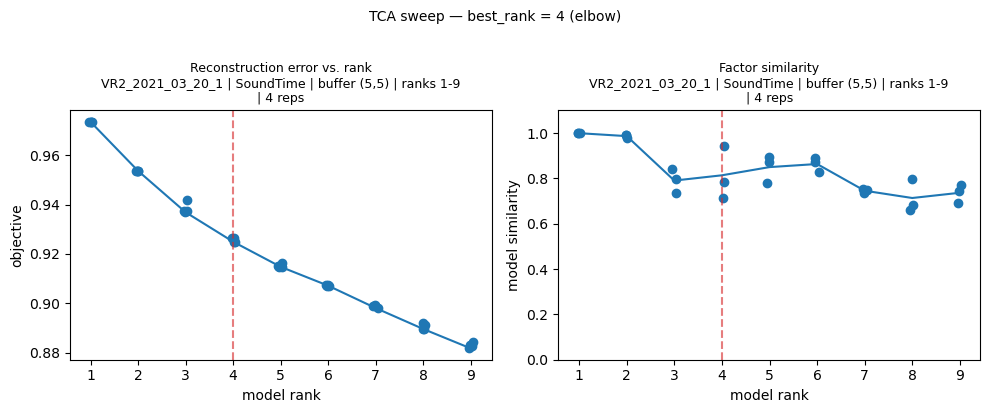

Selected best_rank = 4 (elbow on reconstruction error)
best_rep_idx = {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}


In [20]:
# Compatibility: scipy.random was removed in recent SciPy; tensortools still uses it
import scipy
if not hasattr(scipy, 'random'):
    import numpy.random
    scipy.random = numpy.random

import tensortools as tt
import matplotlib.pyplot as plt

# Build small speed-corrected tensor for Step 3 (uses buffer_small and trial_ts_test from Step 2 test)

run_speed_small = beh['ft_RunSpeed'][: len(ft)]

tensor_small_raw = create_3d_matrix(trial_ts_test, BUFFER_SOUND, spikes, ft)
n_neurons, n_time, n_trials = tensor_small_raw.shape
speed_matrix_small = create_speed_matrix(trial_ts_test, BUFFER_SOUND, ft, run_speed_small)

correct_by_step3 = "simple"  # "simple" (Option A) or "bytrial" (Option B)
tensor_small = speed_correct_tensor(
    tensor_small_raw, speed_matrix_small, n_neurons, n_time, n_trials, correct_by=correct_by_step3
)

# Step 3: small rank range and replicates for quick test
rank_range = range(1, 10)   # ranks 1, 2, 3
replicates = 4

# Alignment and buffer used for this run (for titles and filename)
# alignment_name = "Trial_start_time"  # tunnel entrance
alignment_name = "SoundTime"  # tunnel entrance
buffer_used = BUFFER_SOUND  # (2, 2) for Step 3 test
# Option 1: The method "cp_als" fits a unconstrained tensor decomposition
ensemble_rank_sweep = tt.Ensemble(fit_method="cp_als")

# Option 2: The method "ncp_hals" fits a nonnegative tensor decomposition
# ensemble_rank_sweep = tt.Ensemble(fit_method="ncp_hals")
ensemble_rank_sweep.fit(tensor_small, ranks=rank_range, replicates=replicates)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
tt.plot_objective(ensemble_rank_sweep, ax=axes[0])
tt.plot_similarity(ensemble_rank_sweep, ax=axes[1])

# Descriptive titles: target, alignment, buffer, rank range, replicates (wrap if long)
import textwrap
title_suffix = f"{target_file} | {alignment_name} | buffer ({buffer_used[0]},{buffer_used[1]}) | ranks {min(rank_range)}-{max(rank_range)} | {replicates} reps"
wrapped_suffix = textwrap.fill(title_suffix, width=55)
axes[0].set_title(f"Reconstruction error vs. rank\n{wrapped_suffix}", fontsize=9)
axes[1].set_title(f"Factor similarity\n{wrapped_suffix}", fontsize=9)

# Compute mean reconstruction error and best replicate per rank
orig_norm = np.linalg.norm(tensor_small)
mean_errors = []
best_rep_idx = {}
for r in rank_range:
    reps = ensemble_rank_sweep.factors(r)
    errs = []
    best_idx = 0
    best_err = None
    for i, (U, V, W) in enumerate(reps):
        if U.shape[0] == tensor_small.shape[0] and V.shape[0] == tensor_small.shape[1] and W.shape[0] == tensor_small.shape[2]:
            Xhat = np.einsum('ir,jr,kr->ijk', U, V, W)
        elif U.shape[1] == tensor_small.shape[0] and V.shape[1] == tensor_small.shape[1] and W.shape[1] == tensor_small.shape[2]:
            Xhat = np.einsum('ri,rj,rk->ijk', U, V, W)
        else:
            raise ValueError(f"Unexpected factor shapes for rank {r}: {[a.shape for a in (U, V, W)]}")
        err = np.linalg.norm(tensor_small - Xhat) / (orig_norm + 1e-12)
        errs.append(err)
        if best_err is None or err < best_err:
            best_err = err
            best_idx = i
    mean_errors.append(float(np.mean(errs)))
    best_rep_idx[int(r)] = int(best_idx)

# Elbow heuristic on error curve
x = np.arange(len(mean_errors), dtype=float) + 1.0
y = np.array(mean_errors, dtype=float)
m = (y[-1] - y[0]) / (x[-1] - x[0] + 1e-12)
b = y[0] - m * x[0]
dist = np.abs(m * x + b - y) / (np.sqrt(m * m + 1.0) + 1e-12)
elbow_rank = int(x[np.argmax(dist)])
best_rank = int(max(1, elbow_rank))

for ax in axes:
    ax.axvline(best_rank, color='tab:red', linestyle='--', alpha=0.6)
fig.suptitle(f"TCA sweep — best_rank = {best_rank} (elbow)", fontsize=10, y=1.02)
plt.tight_layout()

# Save plot with naming convention: objective_similarity_{target}_{alignment}_buffer{b}-{b}_r{min}-{max}_rep{n}_best{best}.png
plot_filename = results_dir / (
    f"objective_similarity_{target_file}_{alignment_name}_buffer{buffer_used[0]}-{buffer_used[1]}_"
    f"r{min(rank_range)}-{max(rank_range)}_rep{replicates}_best{best_rank}.png"
)
plt.savefig(plot_filename, dpi=150, bbox_inches='tight')
print(f"Plot saved to {plot_filename}")
plt.show()

print(f"Selected best_rank = {best_rank} (elbow on reconstruction error)")
print(f"best_rep_idx = {best_rep_idx}")

## Step 4: Save payload (tpca format + ordering + metadata)

Save ensemble and all info needed for self-contained load and visualization: same keys as tpca plus neuron_order, frame_order, trial_order, beh_field, buffer, trial_to_stim, and neuron_to_area (from trans file, computed before TCA).

In [21]:
import pickle

# Dataset label (sup_bef, unsup_bef, etc.) for filename and payload
candidates = {"sup_bef": sup_bef, "sup_aft": sup_aft, "unsup_bef": unsup_bef, "unsup_aft": unsup_aft}
dataset_id = target_file
dataset_label = next((k for k, v in candidates.items() if v == dataset_id), "unknown")

# Ordering used in the tensor (must match tensor_small dimensions)
n_neurons, n_time, n_trials = tensor_small.shape
neuron_order = np.arange(n_neurons)  # neuron index in tensor = 0 .. n_neurons-1
# Time axis: relative frames (negative = before, 0 = alignment, positive = after)
frame_order = np.arange(-buffer_used[0], buffer_used[1] + 1, dtype=int)  # e.g. (2,8) → [-2,-1,0,1,...,8]
assert len(frame_order) == n_time, f"frame_order length {len(frame_order)} != n_time {n_time}"
trial_order = np.asarray(beh["trInd"][:n_trials_test], dtype=int)  # actual trial IDs for first n_trials_test trials

# TrialStim per trial (for visualization)
trial_to_stim = dict(zip(trial_order, beh["TrialStim"][:n_trials_test]))

# Filename: same style as tpca, plus alignment and buffer for clarity
fname = (
    f"ensemble_{dataset_label}_{dataset_id}_{alignment_name}_buffer{buffer_used[0]}-{buffer_used[1]}_"
    f"{ensemble_rank_sweep._fit_method.__name__}_"
    f"r{min(rank_range)}-{max(rank_range)}_rep{replicates}.pkl"
)
save_path = results_dir / fname

payload = {
    "ensemble": ensemble_rank_sweep,
    "best_rank": int(best_rank),
    "rank_range": list(rank_range),
    "replicates": int(replicates),
    "best_rep_idx": {int(k): int(v) for k, v in best_rep_idx.items()},
    "dataset_label": dataset_label,
    "dataset_id": dataset_id,
    "spike_file": spike_path,
    "beh_path": beh_path,
    "neuron_order": neuron_order,
    "frame_order": frame_order,
    "trial_order": trial_order,
    "beh_field": alignment_name,
    "buffer": tuple(buffer_used),
    "trial_to_stim": trial_to_stim,
    "neuron_to_area": neuron_to_area,
}

with open(save_path, "wb") as f:
    pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)

print(f"Saved: {save_path}")
print(f"Payload keys: {list(payload.keys())}")

Saved: /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/4replicas_10components_10frames/ensemble_sup_bef_VR2_2021_03_20_1_SoundTime_buffer5-5_cp_als_r1-9_rep4.pkl
Payload keys: ['ensemble', 'best_rank', 'rank_range', 'replicates', 'best_rep_idx', 'dataset_label', 'dataset_id', 'spike_file', 'beh_path', 'neuron_order', 'frame_order', 'trial_order', 'beh_field', 'buffer', 'trial_to_stim', 'neuron_to_area']


In [16]:
# Load and verify saved payload
with open(save_path, "rb") as f:
    loaded = pickle.load(f)

print("Loaded keys:", list(loaded.keys()))
print("best_rank:", loaded["best_rank"], "| best_rep_idx:", loaded["best_rep_idx"])
print("neuron_order len:", len(loaded["neuron_order"]), "| frame_order len:", len(loaded["frame_order"]), "| trial_order len:", len(loaded["trial_order"]))
print("trial_to_stim sample:", dict(list(loaded["trial_to_stim"].items())[:5]))
# Quick shape check: factors for best_rank should match ordering lengths
R = loaded["best_rank"]
rep_idx = loaded["best_rep_idx"].get(R, 0)
factors = loaded["ensemble"].factors(R)[rep_idx]
U, V, W = factors
assert U.shape[0] == len(loaded["neuron_order"]) and V.shape[0] == len(loaded["frame_order"]) and W.shape[0] == len(loaded["trial_order"]), "Factor shapes don't match ordering"
print("Factor shapes match ordering. OK.")

Loaded keys: ['ensemble', 'best_rank', 'rank_range', 'replicates', 'best_rep_idx', 'dataset_label', 'dataset_id', 'spike_file', 'beh_path', 'neuron_order', 'frame_order', 'trial_order', 'beh_field', 'buffer', 'trial_to_stim', 'neuron_to_area']
best_rank: 5 | best_rep_idx: {1: 0, 2: 0, 3: 0, 4: 0, 5: 0, 6: 0, 7: 0, 8: 0, 9: 0}
neuron_order len: 81473 | frame_order len: 11 | trial_order len: 348
trial_to_stim sample: {np.int64(0): np.str_('leaf1'), np.int64(1): np.str_('leaf1'), np.int64(2): np.str_('circle1'), np.int64(3): np.str_('leaf1'), np.int64(4): np.str_('circle1')}
Factor shapes match ordering. OK.


## Step 5: Visualize factors (load from pickle, same grid as tpca)

Load the saved payload, get factors for `best_rank`, and plot the component grid: U (neurons) scatter, V (time) line, W (trials) scatter. Same layout, y-limits, and TrialStim palette as tpca. Neuron panel uses `neuron_to_area` from payload if present, else a single group.

Plot saved to /Users/johnmadrid/GitHub/isp-unsupervised-learning/results/4replicas_10components_10frames/tensor_components_grid_sup_bef_VR2_2021_03_20_1_SoundTime_buffer5-5-SIMPLE_Method-cp_als_speed_correctionNEW.png


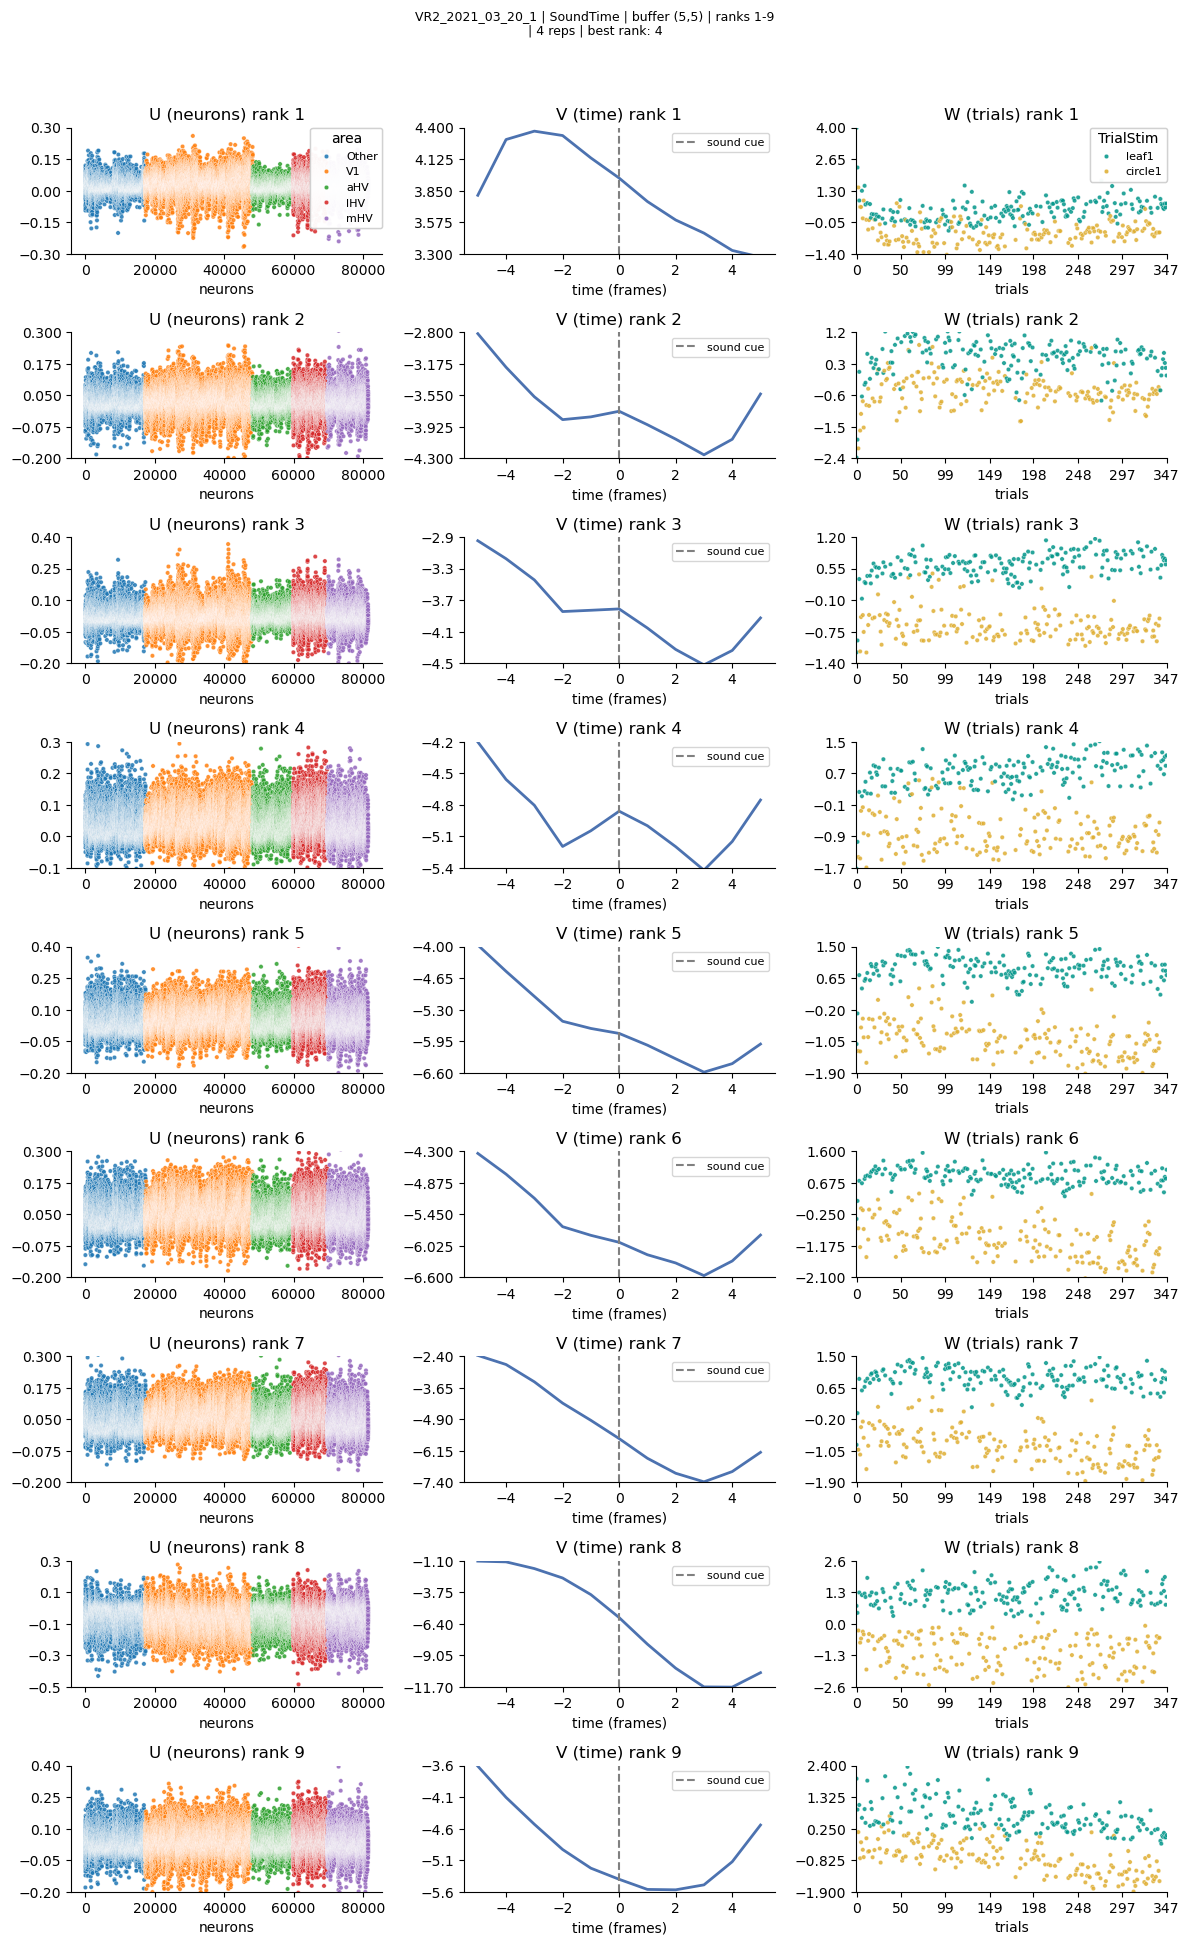

In [22]:
# Load from pickle (use save_path from Step 4, or set load_path to a specific file)
import textwrap
import matplotlib.pyplot as plt
import matplotlib.ticker as mpl_ticker
import seaborn as sns

load_path = save_path  # or e.g. results_dir / "ensemble_sup_bef_..._r1-3_rep2.pkl"
with open(load_path, "rb") as f:
    data = pickle.load(f)

# Plot all calculated ranks (one row per rank, first component only)
rank_range = data.get("rank_range", range(1, data["best_rank"] + 1))
if not isinstance(rank_range, list):
    rank_range = list(rank_range)
ranks_list = rank_range
n_ranks = len(ranks_list)
neuron_order = data["neuron_order"]
frame_order = data["frame_order"]
trial_order = data["trial_order"]
trial_to_stim = data["trial_to_stim"]
if isinstance(trial_to_stim, dict):
    trial_to_stim = pd.Series(trial_to_stim)
neuron_to_area = data.get("neuron_to_area")
if neuron_to_area is None:
    neuron_to_area = pd.Series("n/a", index=neuron_order)
elif isinstance(neuron_to_area, dict):
    neuron_to_area = pd.Series(neuron_to_area)

fig_height = max(2.5, min(2.2 * n_ranks, 28))
fig, axes = plt.subplots(n_ranks, 3, figsize=(12, fig_height), sharex=False)
if n_ranks == 1:
    axes = np.array([axes])

title_suffix = (f"{data['dataset_id']} | {data['beh_field']} | buffer ({data['buffer'][0]},{data['buffer'][1]}) | "
                f"ranks {min(rank_range)}-{max(rank_range)} | {data['replicates']} reps | best rank: {data['best_rank']}")
fig.suptitle(textwrap.fill(title_suffix, width=55), fontsize=9)

for k, r in enumerate(ranks_list):
    rep_idx = data["best_rep_idx"].get(r, 0)
    factors = data["ensemble"].factors(r)[rep_idx]
    aU, aV, aW = factors  # first component only for this row
    u1, v1, w1 = aU[:, 0], aV[:, 0], aW[:, 0]
    u_min, u_max = round(float(np.nanmin(u1)), 1), round(float(np.nanmax(u1)), 1)
    v_min, v_max = round(float(np.nanmin(v1)), 1), round(float(np.nanmax(v1)), 1)
    w_min, w_max = round(float(np.nanmin(w1)), 1), round(float(np.nanmax(w1)), 1)

    ax0 = axes[k, 0]
    neu_df = pd.DataFrame({"neuron": neuron_order, "loading": u1})
    neu_df["area"] = neu_df["neuron"].map(neuron_to_area)
    neu_df = neu_df.sort_values(["area", "neuron"]).reset_index(drop=True)
    neu_df["neuron_idx"] = np.arange(len(neu_df))
    sns.scatterplot(data=neu_df, x="neuron_idx", y="loading", hue="area", s=10, alpha=0.85, ax=ax0, legend=(k == 0))
    ax0.set_title(f"U (neurons) rank {r}")
    ax0.set_xlabel("neurons")
    ax0.set_ylabel("")
    ax0.set_ylim(u_min, u_max)
    ax0.set_yticks(np.linspace(u_min, u_max, num=5))
    sns.despine(ax=ax0, top=True, right=True)

    ax1 = axes[k, 1]
    time_df = pd.DataFrame({"frame": frame_order, "loading": v1})
    sns.lineplot(data=time_df, x="frame", y="loading", ax=ax1, color=sns.color_palette("deep")[0], linewidth=2)
    ax1.set_title(f"V (time) rank {r}")
    ax1.set_xlabel("time (frames)")
    ax1.set_ylabel("")
    ax1.set_ylim(v_min, v_max)
    ax1.set_yticks(np.linspace(v_min, v_max, num=5))
    ax1.xaxis.set_major_locator(mpl_ticker.MaxNLocator(integer=True))
    align_label = "tunnel entrance" if data.get("beh_field") == "Trial_start_time" else "sound cue" if data.get("beh_field") == "SoundTime" else data.get("beh_field", "alignment")
    ax1.axvline(0, color="gray", linestyle="--", linewidth=1.5, label=align_label)
    ax1.legend(loc="best", fontsize=8)
    sns.despine(ax=ax1, top=True, right=True)

    ax2 = axes[k, 2]
    tr_df = pd.DataFrame({"ft_trInd": trial_order, "loading": w1})
    tr_df["TrialStim"] = tr_df["ft_trInd"].map(trial_to_stim)
    custom_trialstim_palette = {"circle1": "#DFAE32", "leaf1": "#02968a"}
    sns.scatterplot(data=tr_df, x="ft_trInd", y="loading", hue="TrialStim", s=10, alpha=0.85, ax=ax2, legend=(k == 0), palette=custom_trialstim_palette)
    ax2.set_title(f"W (trials) rank {r}")
    ax2.set_xlabel("trials")
    ax2.set_ylabel("")
    ax2.set_ylim(w_min, w_max)
    ax2.set_yticks(np.linspace(w_min, w_max, num=5))
    t_min, t_max = int(trial_order.min()), int(trial_order.max())
    n_ticks = min(8, t_max - t_min + 1)
    ticks = np.unique(np.round(np.linspace(t_min, t_max, num=n_ticks)).astype(int))
    if len(ticks) == 0 or ticks[-1] != t_max:
        ticks = np.append(ticks, t_max)
    ax2.set_xticks(ticks)
    ax2.set_xlim(t_min - 0.5, t_max + 0.5)
    sns.despine(ax=ax2, top=True, right=True)

if n_ranks >= 1:
    leg0 = axes[0, 0].legend(title="area", fontsize=8, loc="upper right", borderaxespad=0.0)
    if leg0 is not None:
        axes[0, 0].add_artist(leg0)
    leg2 = axes[0, 2].legend(title="TrialStim", fontsize=8, loc="upper right", borderaxespad=0.0)
    if leg2 is not None:
        axes[0, 2].add_artist(leg2)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # leave room for suptitle
plot_filename = results_dir / (
    f"tensor_components_grid_{data['dataset_label']}_{data['dataset_id']}_{data['beh_field']}_"
    f"buffer{data['buffer'][0]}-{data['buffer'][1]}-SIMPLE_Method-cp_als_speed_correctionNEW.png"
)
plt.savefig(plot_filename, dpi=150, bbox_inches="tight")
print(f"Plot saved to {plot_filename}")
plt.show()

## Step 6: Full batch run (all targets × both alignments)

Runs TCA for **all four target files** (sup_bef, sup_aft, unsup_bef, unsup_aft) and **both alignments** (tunnel: `Trial_start_time` buffer (2,8); sound: `SoundTime` buffer (5,5)), with **ranks 1–10** and **4 replicas**. For each target, uses the correct Beh_, SVD_dec, and trans files. Saves ensemble payloads and component grid figures to `results/4replicas_10components_10frames/`.

In [31]:
# Step 6: Full batch — all targets, both alignments, full ranks/replicas
import pickle
import textwrap
import matplotlib.pyplot as plt
import matplotlib.ticker as mpl_ticker
import seaborn as sns

# scipy.random compatibility for tensortools
import scipy
if not hasattr(scipy, 'random'):
    import numpy.random
    scipy.random = numpy.random
import tensortools as tt

# Targets: (target_file id, dataset_label for filenames)
TARGETS = [
    (sup_bef, "sup_bef"),
    (sup_aft, "sup_aft"),
    (unsup_bef, "unsup_bef"),
    (unsup_aft, "unsup_aft"),
]
# Buffers we will use later: tunnel (2 before, 8 after), sound (5 before, 5 after)
BUFFER_TUNNEL = (2, 8)   # frames before/after tunnel entrance (Trial_start_time)
BUFFER_SOUND = (5, 5)    # frames before/after sound cue (SoundTime)

# Alignments: (beh key for timestamps, buffer (n_before, n_after))
ALIGNMENTS = [
    ("Trial_start_time", BUFFER_TUNNEL),   # tunnel entrance: (2, 8)
    ("SoundTime", BUFFER_SOUND),           # sound cue: (5, 5)
]
rank_range = range(1, 11)  # for 10 components (ranks 1–11)
replicates = 4


def _plot_and_save_components(data, results_dir):
    """Plot all calculated ranks (one row per rank, first component only), same style as Step 5."""
    rank_range = data.get("rank_range", range(1, data["best_rank"] + 1))
    if not isinstance(rank_range, list):
        rank_range = list(rank_range)
    ranks_list = rank_range
    n_ranks = len(ranks_list)
    neuron_order = data["neuron_order"]
    frame_order = data["frame_order"]
    trial_order = data["trial_order"]
    trial_to_stim = data["trial_to_stim"]
    if isinstance(trial_to_stim, dict):
        trial_to_stim = pd.Series(trial_to_stim)
    neuron_to_area = data.get("neuron_to_area")
    if neuron_to_area is None:
        neuron_to_area = pd.Series("n/a", index=neuron_order)
    elif isinstance(neuron_to_area, dict):
        neuron_to_area = pd.Series(neuron_to_area)

    fig_height = max(2.5, min(2.2 * n_ranks, 28))
    fig, axes = plt.subplots(n_ranks, 3, figsize=(12, fig_height), sharex=False)
    if n_ranks == 1:
        axes = np.array([axes])
    title_suffix = (f"{data['dataset_id']} | {data['beh_field']} | buffer ({data['buffer'][0]},{data['buffer'][1]}) | "
                    f"ranks {min(rank_range)}-{max(rank_range)} | {data['replicates']} reps | best rank: {data['best_rank']}")
    fig.suptitle(textwrap.fill(title_suffix, width=55), fontsize=9)

    for k, r in enumerate(ranks_list):
        rep_idx = data["best_rep_idx"].get(r, 0)
        factors = data["ensemble"].factors(r)[rep_idx]
        aU, aV, aW = factors
        u1, v1, w1 = aU[:, 0], aV[:, 0], aW[:, 0]
        u_min, u_max = round(float(np.nanmin(u1)), 1), round(float(np.nanmax(u1)), 1)
        v_min, v_max = round(float(np.nanmin(v1)), 1), round(float(np.nanmax(v1)), 1)
        w_min, w_max = round(float(np.nanmin(w1)), 1), round(float(np.nanmax(w1)), 1)

        ax0 = axes[k, 0]
        neu_df = pd.DataFrame({"neuron": neuron_order, "loading": u1})
        neu_df["area"] = neu_df["neuron"].map(neuron_to_area)
        neu_df = neu_df.sort_values(["area", "neuron"]).reset_index(drop=True)
        neu_df["neuron_idx"] = np.arange(len(neu_df))
        sns.scatterplot(data=neu_df, x="neuron_idx", y="loading", hue="area", s=10, alpha=0.85, ax=ax0, legend=(k == 0))
        ax0.set_title(f"U (neurons) rank {r}")
        ax0.set_xlabel("neurons")
        ax0.set_ylabel("")
        ax0.set_ylim(u_min, u_max)
        ax0.set_yticks(np.linspace(u_min, u_max, num=5))
        sns.despine(ax=ax0, top=True, right=True)

        ax1 = axes[k, 1]
        time_df = pd.DataFrame({"frame": frame_order, "loading": v1})
        sns.lineplot(data=time_df, x="frame", y="loading", ax=ax1, color=sns.color_palette("deep")[0], linewidth=2)
        ax1.set_title(f"V (time) rank {r}")
        ax1.set_xlabel("time (frames)")
        ax1.set_ylabel("")
        ax1.set_ylim(v_min, v_max)
        ax1.set_yticks(np.linspace(v_min, v_max, num=5))
        ax1.xaxis.set_major_locator(mpl_ticker.MaxNLocator(integer=True))
        align_label = "tunnel entrance" if data.get("beh_field") == "Trial_start_time" else "sound cue" if data.get("beh_field") == "SoundTime" else data.get("beh_field", "alignment")
        ax1.axvline(0, color="gray", linestyle="--", linewidth=1.5, label=align_label)
        ax1.legend(loc="best", fontsize=8)
        sns.despine(ax=ax1, top=True, right=True)

        ax2 = axes[k, 2]
        tr_df = pd.DataFrame({"ft_trInd": trial_order, "loading": w1})
        tr_df["TrialStim"] = tr_df["ft_trInd"].map(trial_to_stim)
        custom_trialstim_palette = {"circle1": "#DFAE32", "leaf1": "#02968a"}
        sns.scatterplot(data=tr_df, x="ft_trInd", y="loading", hue="TrialStim", s=10, alpha=0.85,
                        ax=ax2, legend=(k == 0), palette=custom_trialstim_palette)
        ax2.set_title(f"W (trials) rank {r}")
        ax2.set_xlabel("trials")
        ax2.set_ylabel("")
        ax2.set_ylim(w_min, w_max)
        ax2.set_yticks(np.linspace(w_min, w_max, num=5))
        t_min, t_max = int(trial_order.min()), int(trial_order.max())
        n_ticks = min(8, t_max - t_min + 1)
        ticks = np.unique(np.round(np.linspace(t_min, t_max, num=n_ticks)).astype(int))
        if len(ticks) == 0 or ticks[-1] != t_max:
            ticks = np.append(ticks, t_max)
        ax2.set_xticks(ticks)
        ax2.set_xlim(t_min - 0.5, t_max + 0.5)
        sns.despine(ax=ax2, top=True, right=True)

    if n_ranks >= 1:
        leg0 = axes[0, 0].legend(title="area", fontsize=8, loc="upper right", borderaxespad=0.0)
        if leg0 is not None:
            axes[0, 0].add_artist(leg0)
        leg2 = axes[0, 2].legend(title="TrialStim", fontsize=8, loc="upper right", borderaxespad=0.0)
        if leg2 is not None:
            axes[0, 2].add_artist(leg2)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plot_filename = results_dir / (
        f"tensor_components_grid_{data['dataset_label']}_{data['dataset_id']}_{data['beh_field']}_"
        f"buffer{data['buffer'][0]}-{data['buffer'][1]}.png"
    )
    plt.savefig(plot_filename, dpi=150, bbox_inches="tight")
    plt.close()
    return plot_filename


for target_file, dataset_label in TARGETS:
    # Per-target files: SVD_dec, Beh, and trans (neuron areas)
    spike_path = os.path.join(data_root, target_file + "_SVD_dec.npy")
    beh_filename = get_beh_path(target_file)
    beh_path = os.path.join(data_root, beh_filename)

    if not os.path.isfile(spike_path):
        print(f"Skip {target_file}: missing {spike_path}")
        continue
    if not os.path.isfile(beh_path):
        print(f"Skip {target_file}: missing {beh_path}")
        continue

    # Load spikes and behavior for this target
    svd_data = np.load(spike_path, allow_pickle=True).item()
    spikes = (svd_data["U"].T @ svd_data["V"]).T  # (n_timepoints, n_neurons)
    beh_all = np.load(beh_path, allow_pickle=True).item()
    beh = beh_all[target_file]
    ft = beh["ft"][: spikes.shape[0] + 1]
    neuron_to_area = load_neuron_to_area_from_trans(data_root, target_file)
    assert len(neuron_to_area) == spikes.shape[1], f"Trans neurons {len(neuron_to_area)} vs spike neurons {spikes.shape[1]}"

    for alignment_name, buffer_used in ALIGNMENTS:
        # Timestamps: Trial_start_time = tunnel entrance; SoundTime = sound cue. Buffer = (n_before, n_after) frames around that event.
        trial_timestamps = beh[alignment_name]
        n_trials = len(trial_timestamps)
        # Build raw tensor (neurons x time x trials), then apply simple speed correction before TCA.
        tensor_raw = create_3d_matrix(trial_timestamps, buffer_used, spikes, ft)
        n_neurons, n_time, n_trials_actual = tensor_raw.shape
        assert n_trials_actual == n_trials
        run_speed = beh["ft_RunSpeed"][: len(ft)]
        speed_matrix = create_speed_matrix(trial_timestamps, buffer_used, ft, run_speed)
        # Simple correction (Option A): activity ~ 1 + speed; use residuals for TCA. Use correct_by="bytrial" for Option B.
        tensor_corrected = speed_correct_tensor(tensor_raw, speed_matrix, n_neurons, n_time, n_trials, correct_by="simple")

        print(f"Fitting {dataset_label} {target_file} | {alignment_name} buffer {buffer_used} | "
              f"tensor {tensor_corrected.shape} | ranks 1–{max(rank_range)} x {replicates} reps ...")
        
        # Option 1: The method "cp_als" fits a unconstrained tensor decomposition
        # ensemble = tt.Ensemble(fit_method="cp_als")

        # Option 2: The method "ncp_hals" fits a nonnegative tensor decomposition
        ensemble = tt.Ensemble(fit_method="ncp_hals")
        # TCA is fit on the speed-corrected tensor (residuals from simple model).
        ensemble.fit(tensor_corrected, ranks=rank_range, replicates=replicates)

        orig_norm = np.linalg.norm(tensor_corrected)
        mean_errors = []
        best_rep_idx = {}
        for r in rank_range:
            reps = ensemble.factors(r)
            best_idx = 0
            best_err = None
            for i, (U, V, W) in enumerate(reps):
                if U.shape[0] == tensor_corrected.shape[0] and V.shape[0] == tensor_corrected.shape[1] and W.shape[0] == tensor_corrected.shape[2]:
                    Xhat = np.einsum("ir,jr,kr->ijk", U, V, W)
                elif U.shape[1] == tensor_corrected.shape[0] and V.shape[1] == tensor_corrected.shape[1] and W.shape[1] == tensor_corrected.shape[2]:
                    Xhat = np.einsum("ri,rj,rk->ijk", U, V, W)
                else:
                    raise ValueError(f"Unexpected factor shapes for rank {r}")
                err = np.linalg.norm(tensor_corrected - Xhat) / (orig_norm + 1e-12)
                if best_err is None or err < best_err:
                    best_err = err
                    best_idx = i
            mean_errors.append(float(np.mean([np.linalg.norm(tensor_corrected - np.einsum("ir,jr,kr->ijk", *ensemble.factors(r)[j])) / (orig_norm + 1e-12) for j in range(len(ensemble.factors(r)))])))
            best_rep_idx[int(r)] = int(best_idx)

        x = np.arange(len(mean_errors), dtype=float) + 1.0
        y = np.array(mean_errors, dtype=float)
        m = (y[-1] - y[0]) / (x[-1] - x[0] + 1e-12)
        b = y[0] - m * x[0]
        dist = np.abs(m * x + b - y) / (np.sqrt(m * m + 1.0) + 1e-12)
        elbow_rank = int(x[np.argmax(dist)])
        best_rank = max(1, elbow_rank)

        frame_order = np.arange(-buffer_used[0], buffer_used[1] + 1, dtype=int)
        trial_order = np.asarray(beh["trInd"][:n_trials], dtype=int)
        trial_to_stim = dict(zip(trial_order, beh["TrialStim"][:n_trials]))
        neuron_order = np.arange(n_neurons)

        fname = (
            f"ensemble_{dataset_label}_{target_file}_{alignment_name}_buffer{buffer_used[0]}-{buffer_used[1]}_"
            f"ncp_hals_r{min(rank_range)}-{max(rank_range)}_rep{replicates}.pkl"
        )
        save_path = results_dir / fname
        payload = {
            "ensemble": ensemble,
            "best_rank": best_rank,
            "rank_range": list(rank_range),
            "replicates": replicates,
            "best_rep_idx": best_rep_idx,
            "dataset_label": dataset_label,
            "dataset_id": target_file,
            "spike_file": spike_path,
            "beh_path": beh_path,
            "neuron_order": neuron_order,
            "frame_order": frame_order,
            "trial_order": trial_order,
            "beh_field": alignment_name,
            "buffer": tuple(buffer_used),
            "trial_to_stim": trial_to_stim,
            "neuron_to_area": neuron_to_area,
        }
        with open(save_path, "wb") as f:
            pickle.dump(payload, f, protocol=pickle.HIGHEST_PROTOCOL)
        print(f"  Saved {save_path.name} (best_rank={best_rank})")

        with open(save_path, "rb") as f:
            loaded = pickle.load(f)
        plot_path = _plot_and_save_components(loaded, results_dir)
        print(f"  Plot saved {plot_path.name}")

print("Done.")

Fitting sup_bef VR2_2021_03_20_1 | Trial_start_time buffer (2, 8) | tensor (81473, 11, 348) | ranks 1–10 x 4 reps ...


Rank-1 models:  min obj, 0.97;  max obj, 0.97;  time to fit, 60.3s


Rank-2 models:  min obj, 0.96;  max obj, 0.96;  time to fit, 137.3s


Rank-3 models:  min obj, 0.94;  max obj, 0.94;  time to fit, 133.9s


Rank-4 models:  min obj, 0.94;  max obj, 0.94;  time to fit, 137.4s


...

Rank-6 models:  min obj, 0.92;  max obj, 0.93;  time to fit, 290.8s


Rank-7 models:  min obj, 0.92;  max obj, 0.92;  time to fit, 312.2s


Rank-8 models:  min obj, 0.91;  max obj, 0.91;  time to fit, 201.0s


Rank-9 models:  min obj, 0.90;  max obj, 0.91;  time to fit, 379.6s


KeyboardInterrupt: 